# RABI

In [6]:
%load_ext autoreload
%autoreload 2
from FIFOv4 import FIFO
import matplotlib.pyplot as plt
import numpy as np
import math
from spcm import units
import spcm as spcm
import time as time
from time import sleep 
# import API classes into the current namespace
from pulsestreamer import PulseStreamer, Sequence  
import hdawg_driver_latest_v2 as awg
from sg396_driver_v1 import SG396
from pulser import PulseGenerator
# from laser_driver import LaserControl
from thorlabs_laser_shutter_driver import LaserShutter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Connect Instruments

In [7]:
# Digitizer 
FIFO = FIFO('dev/spcm0')

Exception ignored in: <function Device.__del__ at 0x00000205B0A70720>
Traceback (most recent call last):
  File "c:\Users\ejvil\miniconda3\envs\nspyre\Lib\site-packages\spcm\classes_device.py", line 77, in __del__
    self.stop()
  File "c:\Users\ejvil\miniconda3\envs\nspyre\Lib\site-packages\spcm\classes_device.py", line 320, in stop
    self.cmd(M2CMD_CARD_STOP, *args)
  File "c:\Users\ejvil\miniconda3\envs\nspyre\Lib\site-packages\spcm\classes_device.py", line 273, in cmd
    self.set_i(SPC_M2CMD, cmd)
  File "c:\Users\ejvil\miniconda3\envs\nspyre\Lib\site-packages\spcm\classes_device.py", line 439, in set_i
    self._check_error(spcm_dwSetParam_i64(self._handle, register, value))
  File "c:\Users\ejvil\miniconda3\envs\nspyre\Lib\site-packages\spcm\classes_device.py", line 497, in _check_error
    raise SpcmException(self._last_error)
spcm.classes_error_exception.SpcmException: 


SpcmException: dev/spcm0 not found...

In [3]:
# Pulse Streamer 
PSch_MW=2
PSch_Digitizer=1 
PSch_Laser= 3
PS_chmap={'mw':PSch_MW,
          'digtrig':PSch_Digitizer,
          'laser':PSch_Laser}
ip = '10.135.70.193' 
ps = PulseGenerator(ip,PS_chmap)
INF = np.iinfo(np.int64).max


Connect to Pulse Streamer via JSON-RPC.
IP / Hostname: 10.135.70.193
Pulse Streamer 8/2 firmware: v1.5.2
Client software: v1.7.0
Your client software is more up to date than the Pulse Streamer 8/2 firmware. We recommend updating the firmware of your Pulse Streamer 8/2.
For detailed information visit https://www.swabianinstruments.com/pulse-streamer-8-2/downloads/ or contact support@swabianinstruments.com


In [4]:
# AWB
awg = awg.HDAWG('dev8181', '127.0.0.1', 8004)

Trying to connect to dev8181 on interface USB
Connected to dev8181 via data server 127.0.0.1:8004 and interface USB


In [5]:
# Signal Generator 
sg = SG396('TCPIP::10.135.70.65::inst0::INSTR')

connected to SG396 [TCPIP::10.135.70.65::inst0::INSTR]


In [6]:
laser = LaserControl('LAS-08166')
laser_shutter = LaserShutter('68800950')

### Configure Settings

In [7]:
def choose_sideband(opt, nv_freq, side_freq, pulse_axis='x'):
    match pulse_axis:
        case 'y':
            delta = 90
        case _: 
            delta = 0

    match opt:
        case 'Upper':
            frequencies = nv_freq - side_freq
            iq_phases = [delta+90, delta+0]
        case 'Both':
            frequencies = nv_freq - side_freq
            iq_phases = [delta+0, delta+90, delta+90, delta+0] # lower sideband phases + upper sideband phases
        case _:
            frequencies = nv_freq + side_freq
            iq_phases = [delta+0, delta+90]

    return frequencies, iq_phases

In [8]:
import numpy as np


# Define the parameters (as provided)
awg_parameters = {
    "seq": "RABI",
    "i_offset": -2*1e-3, # mV
    "q_offset": -4*1e-3, # mV
    "sideband_power": 450 * 1e-3, # mV
    "sideband_freq": 30*1e6, # MHz
    "iq_phases": [0, 90],
    "num_pts": 100,
    "runs": 400*4,
    'start': 0*1e-9,
    'stop': 400*1e-9,
    'mw_times': None,
    'sig_gen_freq': None,
    'pulse_axis': 'y',
    'sideband': 'lower',
    'freq': 2.32*1e9, #from ODMR
    'rf_power' : 500*1e-6,
    'iters': 1,
    'laser_power':100 } # stay within 300 and 600 uW (generally, but don't exceed 1 mW)

dig_config = {
    'num_pts_in_exp': 2 * awg_parameters['num_pts'], # MW ON + OFF subsequences
    'runs': awg_parameters['runs'], # number of exp. iterations
    'segment_size': 512*10,
    'pretrig_size': 32,
    'readout_ch': int(0),
    'HF_INPUT_50OHM': 1,
    'iters' : awg_parameters['iters']
}

# Calculate sideband frequencies
mw_times = np.linspace(awg_parameters['start'], awg_parameters['stop'], awg_parameters['num_pts']) * 1e9
awg_parameters['mw_times'] = mw_times

In [9]:
sig_gen_freq, iq_phases = choose_sideband(awg_parameters['sideband'], awg_parameters['freq'], awg_parameters['sideband_freq'], awg_parameters['pulse_axis'])

awg_parameters['sig_gen_freq'] = sig_gen_freq
awg_parameters['iq_phases'] = iq_phases

In [10]:
sg.set_frequency(awg_parameters['sig_gen_freq']) # set carrier frequency
sg.set_rf_amplitude(awg_parameters['rf_power']) # set MW power
sg.set_mod_type(7) # quadrature amplitude modulation
sg.set_mod_subtype(1) # no constellation mapping
sg.set_mod_function('IQ', 5) # external modulation
sg.set_mod_toggle(1) # turn on modulation mode

In [11]:
# import ipywidgets as widgets
# from ipywidgets import interactive
# # Create interactive widgets to display the values
# def display_awg_parameters():
#     display(widgets.HTML(value=f"<b>Averaging Sequence: </b>{awg_parameters['seq']}"))
#     display(widgets.HTML(value=f"<b>i_offset: </b>{awg_parameters['i_offset']} mV"))
#     display(widgets.HTML(value=f"<b>q_offset: </b>{awg_parameters['q_offset']} mV"))
#     display(widgets.HTML(value=f"<b>sideband_power: </b>{awg_parameters['sideband_power']} mV"))
#     display(widgets.HTML(value=f"<b>iq_phases: </b>{awg_parameters['iq_phases']}"))
#     display(widgets.HTML(value=f"<b>num_pts: </b>{awg_parameters['num_pts']}"))
#     display(widgets.HTML(value=f"<b>sideband_freqs: </b>{awg_parameters['sideband_freqs']} MHz"))
#     display(widgets.HTML(value=f"<b>runs: </b>{awg_parameters['runs']}"))

#     display(widgets.HTML(value="<br><b>Digitizer Configuration:</b>"))
#     display(widgets.HTML(value=f"<b>num_pts_in_exp: </b>{dig_config['num_pts_in_exp']}"))
#     display(widgets.HTML(value=f"<b>segment_size: </b>{dig_config['segment_size']}"))
#     display(widgets.HTML(value=f"<b>pretrig_size: </b>{dig_config['pretrig_size']}"))
#     display(widgets.HTML(value=f"<b>readout_ch: </b>{dig_config['readout_ch']}"))
#     display(widgets.HTML(value=f"<b>HF_INPUT_50OHM: </b>{dig_config['HF_INPUT_50OHM']}"))

# # Display parameters
# display_awg_parameters()

### Assign Configuration 

In [12]:
print(awg_parameters['i_offset'])
print(awg_parameters['q_offset'])
print(awg_parameters['sideband_power'])
print(awg_parameters['sideband_freq'])
print(awg_parameters['iq_phases'])
print(awg_parameters['mw_times']/1e9)
print(awg_parameters['num_pts'])

-0.002
-0.004
0.45
30000000.0
[90, 180]
[0.00000000e+00 4.04040404e-09 8.08080808e-09 1.21212121e-08
 1.61616162e-08 2.02020202e-08 2.42424242e-08 2.82828283e-08
 3.23232323e-08 3.63636364e-08 4.04040404e-08 4.44444444e-08
 4.84848485e-08 5.25252525e-08 5.65656566e-08 6.06060606e-08
 6.46464646e-08 6.86868687e-08 7.27272727e-08 7.67676768e-08
 8.08080808e-08 8.48484848e-08 8.88888889e-08 9.29292929e-08
 9.69696970e-08 1.01010101e-07 1.05050505e-07 1.09090909e-07
 1.13131313e-07 1.17171717e-07 1.21212121e-07 1.25252525e-07
 1.29292929e-07 1.33333333e-07 1.37373737e-07 1.41414141e-07
 1.45454545e-07 1.49494949e-07 1.53535354e-07 1.57575758e-07
 1.61616162e-07 1.65656566e-07 1.69696970e-07 1.73737374e-07
 1.77777778e-07 1.81818182e-07 1.85858586e-07 1.89898990e-07
 1.93939394e-07 1.97979798e-07 2.02020202e-07 2.06060606e-07
 2.10101010e-07 2.14141414e-07 2.18181818e-07 2.22222222e-07
 2.26262626e-07 2.30303030e-07 2.34343434e-07 2.38383838e-07
 2.42424242e-07 2.46464646e-07 2.50505051e-07

In [13]:
awg.set_sequence(**{'seq': 'Rabi',
                'i_offset': awg_parameters['i_offset'],
                'q_offset': awg_parameters['q_offset'],
                'sideband_power': awg_parameters['sideband_power'],
                'sideband_freq': awg_parameters['sideband_freq'], 
                'iq_phases': awg_parameters['iq_phases'],
                'pi_pulses': awg_parameters['mw_times']/1e9, 
                'num_pts': awg_parameters['num_pts']}) 

AWG COMPILE STATUS:  -1
AWG COMPILE STATUS again:  2
Warning during sequencer compilation:  Compilation started
Detected 1 devices with a total of 1 AWG cores.
Compiling source string
Warning (line: 204): waveform '__playWave_204_300' size 0 is below the minimal waveform length and will be zero-extended to 32 samples
Warning (line: 205): waveform '__playWave_205_301' size 9 is below the minimal waveform length and will be zero-extended to 32 samples
Warning (line: 206): waveform '__playWave_206_302' size 19 is below the minimal waveform length and will be zero-extended to 32 samples
Warning (line: 207): waveform '__playWave_207_303' size 29 is below the minimal waveform length and will be zero-extended to 32 samples
Warning (line: 208): waveform '__playWave_208_304' size 38 is not aligned to 16 samples and will be zero-extended to 48 samples
Warning (line: 210): waveform '__playWave_210_306' size 58 is not aligned to 16 samples and will be zero-extended to 64 samples
Warning (line: 211

In [14]:
FIFO.assign_param(settings_dict=dig_config)
FIFO.config()

SETTINGS: card timeout =  20 s
SETTINGS: # segments =  5120 Sa
SETTINGS: sampling freq =  0.5 GHz
SETTINGS: pretrig size =  32 Sa
SETTINGS: termination =  1
50 ohm impedance? 1


### Configure ODMR Pulse Sequence 

In [15]:
import typing as t

In [16]:
_T = t.TypeVar('_T')

def convert_type(arg: t.Any, converter: _T) -> _T:
    return converter(arg)

In [17]:
readout_time = 10000 # ns 
trig_time = 10 #ns 
initial_delay = 100
singlet_decay = 500
laser_time = 15000 # 15 us 
trig_spot = 70 # where this starts 
clock_time = 10 
MW_buffer_time = 100
awg_trig_time = 10

def Rabi(params):
    '''
    Rabi sequence
    '''
    ## Run a MW pulse of varying duration, then measure the signal
    ## and reference counts from NV.
    # self.total_time = 0
    longest_time = convert_type(round(max(params)), float)
    ## we can measure the pi time on x and on y.
    ## they should be the same, but they technically
    ## have different offsets on our pulse streamer.

    def SingleRabi(iq_on):
        '''
        CREATE SINGLE RABI SEQUENCE TO REPEAT THROUGHOUT EXPERIMENT
        '''

        iq_on = float(round(iq_on)) # convert to proper data type to avoid undesired rpyc netref data type

        '''
        DEFINE SPECIAL TIME INTERVALS FOR EXPERIMENT
        '''
        # padding time to equalize duration of every run (for different vsg_on durations)
        # pad_time = 50000 - self.initial_delay - self.laser_time - self.singlet_decay - iq_on - self.MW_buffer_time - self.readout_time 
        pad_time = longest_time - iq_on

        '''
        DEFINE RELEVANT ON, OFF TIMES FOR DEVICES
        '''

        laser_off1 = initial_delay 
        laser_off2 = singlet_decay + iq_on + MW_buffer_time
        laser_off3 = 100 + pad_time
        # laser_off3 = pad_time + self.rest_time_btw_seqs
        # laser_off4 = laser_off2
        # laser_off5 = self.rest_time_btw_seqs

        # mw I & Q off windows
        iq_off1 = laser_off1 + laser_time + singlet_decay
        iq_off2 = (iq_on - awg_trig_time) + MW_buffer_time + readout_time + laser_off3 # + self.laser_time # + laser_off4 + laser_off5

        # Digitizer trigger timing
        clock_off1 = laser_off1 + laser_time + laser_off2 + trig_spot - clock_time
        clock_off2 = - trig_spot + readout_time + laser_off3
                
        '''
        CONSTRUCT PULSE SEQUENCE
        '''


        # define sequence structure for laser            
        laser_seq = [(laser_off1, 0), (laser_time, 1), (laser_off2, 0), (readout_time, 1), (laser_off3, 0)]
                    #  (laser_off3, 0), (self.laser_time, 1), (laser_off4, 0), (self.readout_time, 1), (laser_off5, 0)]
    
        # define sequence structure for DAQ trigger
        dig_clock_seq = [(clock_off1, 0), (clock_time, 1), (clock_off2, 0)]

        # define sequence structure for MW I and Q when MW = ON
        mw_iq_on_seq = [(iq_off1, 0), (awg_trig_time, 1), (iq_off2, 0)]
        mw_iq_off_seq = [(iq_off1, 0), (awg_trig_time, 0), (iq_off2, 0)]

        # assign sequences to respective channels for seq_on
        laser_ps = laser_seq+laser_seq
        dig_ps = dig_clock_seq+dig_clock_seq
        mw_ps = mw_iq_on_seq+mw_iq_off_seq


        return [laser_ps, dig_ps, mw_ps]

    # seqs = Pulser.createSequence()
    laser_ps_tot=[]
    dig_ps_tot=[]
    mw_ps_tot=[]
    for mw_time in params:
        # seqs += SingleRabi(mw_time)
        laser_ps_tot += SingleRabi(mw_time)[0]
        dig_ps_tot += SingleRabi(mw_time)[1]
        mw_ps_tot += SingleRabi(mw_time)[2]

    return [laser_ps_tot, dig_ps_tot, mw_ps_tot]


In [18]:
sequence=Rabi(awg_parameters['mw_times'])

ps.setDigital("laser", sequence[0]) # digitizer trigger
ps.setDigital("digtrig", sequence[1]) # digitizer trigger
ps.setDigital("mw", sequence[2]) # MW IQ
ps.setTrigger
ps.plotSeq(plot_all=False)

In [19]:
FIFO.config()
FIFO.start_buffer()
laser_shutter.open_shutter()
laser.set_modulation_state('pulsed')
laser.set_analog_control_mode('current')
laser.set_diode_current_realtime(awg_parameters['laser_power'])
laser.laser_on()


SETTINGS: card timeout =  20 s
SETTINGS: # segments =  5120 Sa
SETTINGS: sampling freq =  0.5 GHz
SETTINGS: pretrig size =  32 Sa
SETTINGS: termination =  1
50 ohm impedance? 1


Failed to set command 'CM=100'
Response from Device :'CM=100.00'


In [20]:
sg.set_rf_toggle(1)
ps.stream(n_runs=INF)
DATA=FIFO.acquire()

(80000, 5120, 1)
termination setting: 1.0


In [5]:
FIFO.stop_card()
FIFO.reset()

TypeError: FIFO.stop_card() missing 1 required positional argument: 'self'

In [22]:
# copy=[]
# for i in range(0,10):
#     FIFO.config()
#     sg.set_rf_toggle(1)
#     FIFO.start_buffer()
#     DATA=FIFO.acquire()
#     FIFO.stop_card()
#     FIFO.reset()
#     sg.set_rf_toggle(0)
#     copy.append(DATA)

# LASER OFF

In [23]:
#STOP 
ps.reset()
sg.set_rf_toggle(0)
awg.set_disabled()
laser.laser_off()
laser_shutter.close_shutter()
FIFO.reset()

### Data Post Processing

In [24]:
print(np.shape(DATA))
import pandas as pd

(80000, 5120, 1)


In [25]:
reshaped_data = DATA.squeeze(axis=2)  # Reduces (20000, 5120, 1) to (20000, 5120)
print(reshaped_data)
data_to_save = pd.DataFrame(reshaped_data)

[[ 0.03505859  0.0354248   0.03579102 ...  0.02297363  0.02285156
   0.02260742]
 [ 0.01345215  0.01357422  0.01357422 ...  0.01015625  0.00966797
   0.00991211]
 [ 0.01308594  0.01345215  0.01345215 ...  0.01247559  0.01210938
   0.0128418 ]
 ...
 [-0.12729492 -0.12692871 -0.12741699 ... -0.13413086 -0.13413086
  -0.13364258]
 [-0.12961426 -0.12949219 -0.12949219 ... -0.13181152 -0.1322998
  -0.13278809]
 [-0.1253418  -0.1253418  -0.12521973 ... -0.13681641 -0.13681641
  -0.13620605]]


In [26]:
import os 

In [27]:
# Get current time for the file name
current_time = time.strftime("%m-%d-%y_%H-%M-%S")

# Define the subfolder path
folder_path = 'rabi_optimization_data'

# Create the subfolder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

# Define the file paths for the .txt and .h5 files
awg_filename = os.path.join(folder_path, f"awg_parameters_{current_time}.txt")
h5_filename = os.path.join(folder_path, f"rabi_optimization_{current_time}.h5")

# Save the dictionaries to a text file
with open(awg_filename, 'w') as file:
    file.write("AWG Parameters:\n")
    file.write(str(awg_parameters) + '\n\n')
    file.write("Digital Configuration:\n")
    file.write(str(dig_config) + '\n')

print(f"AWG parameter file saved as {awg_filename}")


data_to_save.to_hdf(h5_filename, key="df", mode="w")

print(f"HDF5 file saved as {h5_filename}")

AWG parameter file saved as rabi_optimization_data\awg_parameters_12-18-24_15-23-19.txt
HDF5 file saved as rabi_optimization_data\rabi_optimization_12-18-24_15-23-19.h5


In [28]:
# df_read = pd.read_hdf('rabi_optimization_data/rabi_optimization_12-18-24_14-17-47.h5', key='df')
df_read = pd.read_hdf(h5_filename, key='df')

DATA= df_read

In [29]:
DATA_mean=np.mean(DATA,axis=1)
segments=(np.shape(DATA)[0])


In [30]:
sig=DATA_mean[::2]
bg=DATA_mean[1::2]

In [31]:
ms1_array = np.ones(awg_parameters['num_pts']) # dark data array
ms0_array = np.ones(awg_parameters['num_pts']) # bright data array

for i in range(awg_parameters['num_pts']):
    ms1_array[i] = np.mean(sig[i::awg_parameters['num_pts']])
    ms0_array[i] = np.mean(bg[i::awg_parameters['num_pts']])
    

In [32]:
#MAKE PI PULSE TIME 


In [33]:
np.shape(DATA)

(80000, 5120)

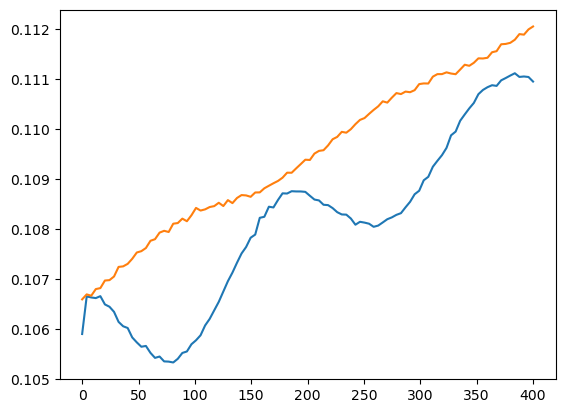

In [34]:
plt.plot(awg_parameters['mw_times'],ms1_array)
plt.plot(awg_parameters['mw_times'],ms0_array)


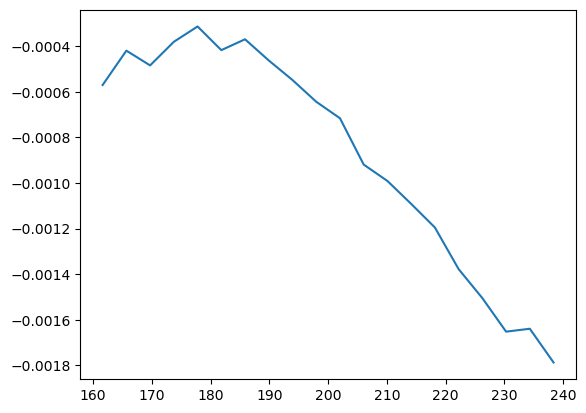

In [35]:
plt.plot(awg_parameters['mw_times'][40:60],ms1_array[40:60]-ms0_array[40:60])

In [36]:
def contrast_math(data,start,stop):
    sliced_data=data[:, start:stop]
    data_mean=np.mean(sliced_data,axis=1)
    sig=data_mean[::2]
    bg=data_mean[1::2]
    sig_mean=np.zeros(awg_parameters['num_pts'])
    bg_mean=np.zeros(awg_parameters['num_pts'])
    for i in range(awg_parameters['runs']):
        for j in range(0,awg_parameters['num_pts']):
            sig_mean[j]+=np.mean(sig[j::awg_parameters['num_pts']])
            bg_mean[j]+=np.mean(bg[j::awg_parameters['num_pts']])
    return(sig_mean,bg_mean)

def contrast_val(data):
    sig, bg = contrast_math(data)
    max_contrast=np.max((bg-sig)/sig)
    return max_contrast

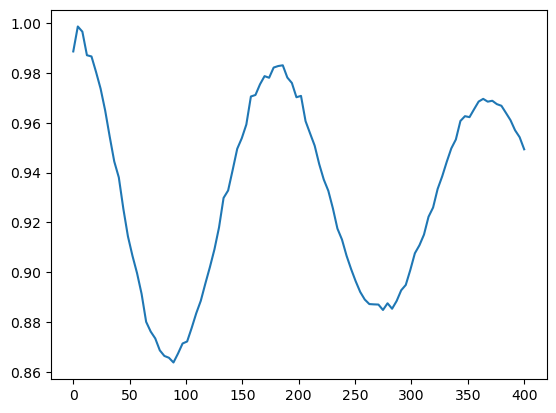

In [37]:
sg , bg = contrast_math(np.array(DATA),0,800)
plt.plot(awg_parameters['mw_times'],sg/bg)


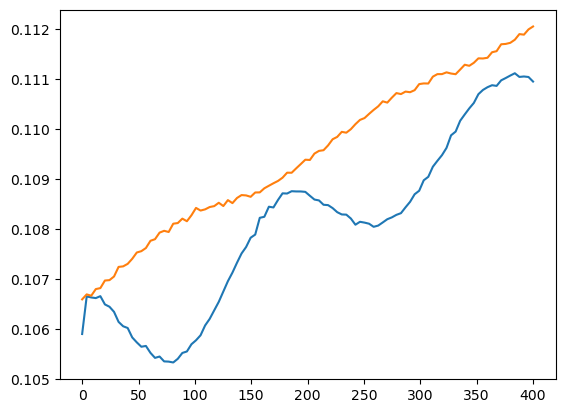

In [38]:
plt.plot(awg_parameters['mw_times'],ms1_array)
plt.plot(awg_parameters['mw_times'],ms0_array)

In [39]:
np.shape(DATA)

(80000, 5120)

In [40]:
DATA=np.array(DATA)

In [41]:
mw_times[23]

92.92929292929293

In [42]:
np.shape(DATA[0::2])

(40000, 5120)

In [43]:
mw_on=DATA[0::2][23::100]
mw_off=DATA[1::2][23::100]

In [44]:
mw_on_plt=np.mean(mw_on,axis=0)
mw_off_plt=np.mean(mw_off,axis=0)

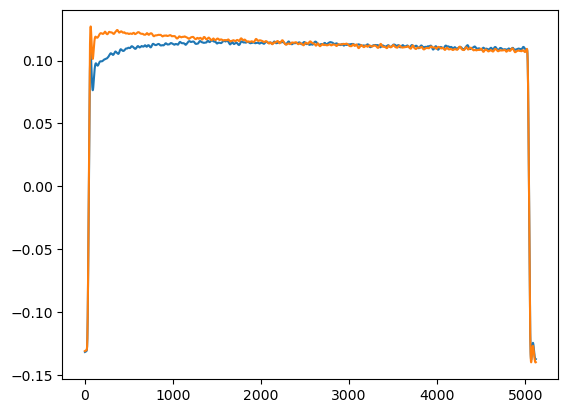

In [45]:
plt.plot(mw_on_plt)
plt.plot(mw_off_plt)

In [46]:
import plotly.graph_objects as go

# Create a plotly figure
fig = go.Figure()

# Add the first trace (mw_on_plt)
fig.add_trace(go.Scatter(y=mw_on_plt, mode='lines', name='MW On'))

# Add the second trace (mw_off_plt)
fig.add_trace(go.Scatter(y=mw_off_plt, mode='lines', name='MW Off'))

# Update the layout (optional)
fig.update_layout(
    title='MW On/Off Plot',
    xaxis_title='X Axis',
    yaxis_title='Y Axis'
)

# Show the plot
fig.show()


In [47]:
def decaying_cos(x, A, T, y0, tau):

    return A*(np.cos(x*2*np.pi/T))*np.exp(-x/tau)+y0

In [48]:
from scipy.optimize import curve_fit

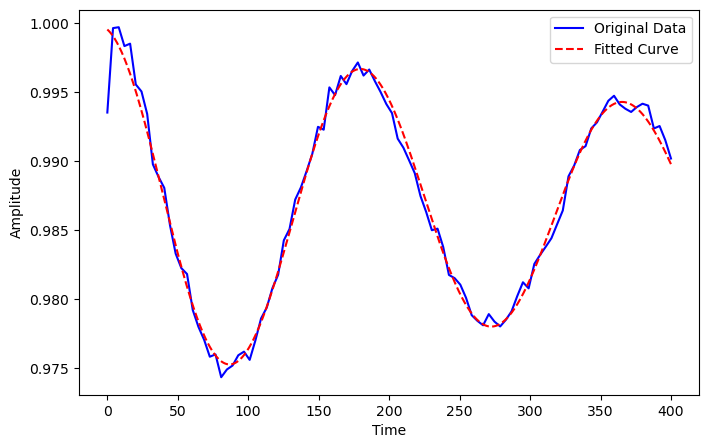

Fitted Parameters:
A = 0.01301, gamma = 0.00147, f = 185.71611, phi = 0.16444, C = 0.98669


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load your data
# Replace x_data, y_data with your x and y values from the plot
x_data = awg_parameters['mw_times']  # Replace with your actual x values
y_data = ms1_array/ms0_array  # Replace with your actual y values

# Define the decaying cosine function
def decaying_cosine(t, A, gamma, T, phi, C):
    return A * np.exp(-gamma * t) * np.cos(2 * np.pi * t / T + phi) + C

# Initial guesses for parameters: A, gamma, f, phi, C
initial_guess = [0.02, 0.001, 200, 0, 1]

# Perform curve fitting
params, covariance = curve_fit(decaying_cosine, x_data, y_data, p0=initial_guess)

# Extract fitted parameters
A_fit, gamma_fit, f_fit, phi_fit, C_fit = params

# Generate fitted curve
x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit = decaying_cosine(x_fit, *params)

# Plot the data and the fitted curve
plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'b-', label="Original Data")
plt.plot(x_fit, y_fit, 'r--', label="Fitted Curve")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Print fitted parameters
print(f"Fitted Parameters:\nA = {A_fit:.5f}, gamma = {gamma_fit:.5f}, f = {f_fit:.5f}, phi = {phi_fit:.5f}, C = {C_fit:.5f}")


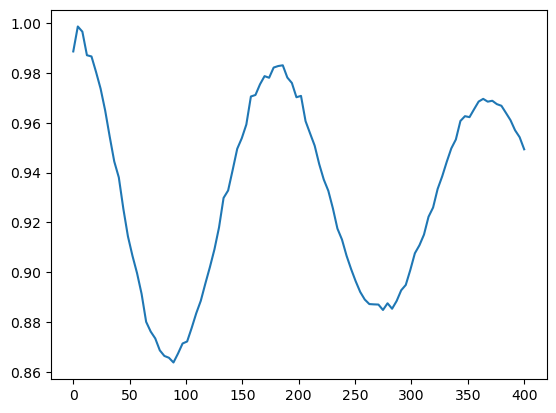

In [ ]:
sg , bg = contrast_math(np.array(DATA),0,800)
plt.plot(awg_parameters['mw_times'],sg/bg)


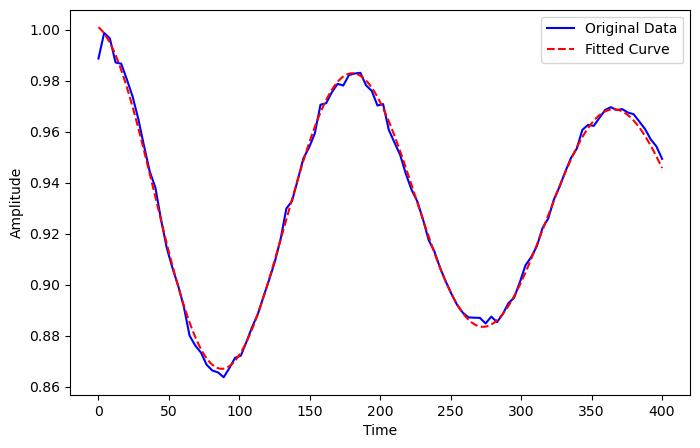

Fitted Parameters:
A = 0.07217, gamma = 0.00165, f = 185.43073, phi = 0.12951, C = 0.92938


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load your data
# Replace x_data, y_data with your x and y values from the plot
x_data = awg_parameters['mw_times']  # Replace with your actual x values
y_data = sg/bg  # Replace with your actual y values

# Define the decaying cosine function
def decaying_cosine(t, A, gamma, T, phi, C):
    return A * np.exp(-gamma * t) * np.cos(2 * np.pi * t / T + phi) + C

# Initial guesses for parameters: A, gamma, f, phi, C
initial_guess = [0.02, 0.001, 200, 0, 1]

# Perform curve fitting
params, covariance = curve_fit(decaying_cosine, x_data, y_data, p0=initial_guess)

# Extract fitted parameters
A_fit, gamma_fit, f_fit, phi_fit, C_fit = params

# Generate fitted curve
x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit = decaying_cosine(x_fit, *params)

# Plot the data and the fitted curve
plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'b-', label="Original Data")
plt.plot(x_fit, y_fit, 'r--', label="Fitted Curve")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Print fitted parameters
print(f"Fitted Parameters:\nA = {A_fit:.5f}, gamma = {gamma_fit:.5f}, f = {f_fit:.5f}, phi = {phi_fit:.5f}, C = {C_fit:.5f}")


In [53]:
np.shape(DATA)

(80000, 5120)

In [ ]:
2*400*100 # num points * runs 

80000

In [67]:
first_quarter=DATA[0:2*100*100,:]

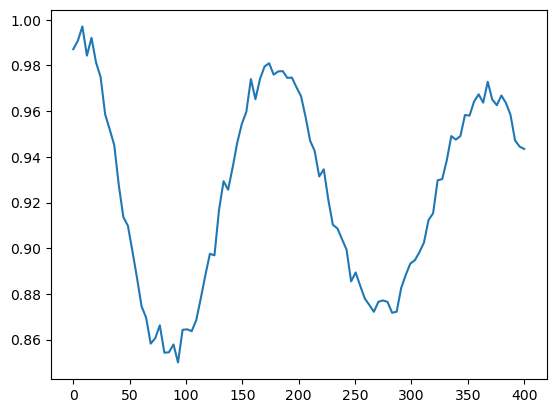

In [71]:
sg , bg = contrast_math(first_quarter,100,500)
plt.plot(awg_parameters['mw_times'],sg/bg)
